In [1]:
import pandas as pd

df = pd.read_csv('../data/funnel_marketing_data.csv')  
df.shape

(3500, 19)

In [2]:
df.head()

,ad_budget,num_leads,leads_answered,leads_not_answered,followup_1,followup_2,followup_3,followup_4,followup_5,not_closed,closed,calls_to_closed,calls_to_not_closed,customer_acquisition_cost,ltv_months,purchased,upsell,cumulative_profit,referred
0,2500,36,24,12,19,14,11,10,7,5,2,2,4,1250,38.0,1,0,20777.0,No
1,15000,98,55,43,43,32,26,25,18,14,4,5,3,3750,10.0,1,0,3531.0,Yes
2,6000,60,35,25,27,19,16,15,11,7,4,5,3,1500,12.0,1,0,3967.0,No
3,4000,48,32,16,25,18,15,13,9,4,5,3,3,800,28.0,1,0,15048.0,Yes
4,1500,25,14,11,10,8,6,6,4,4,0,0,4,0,3.0,0,0,0.0,No


In [3]:
df.isnull().sum()

ad_budget                     0
num_leads                     0
leads_answered                0
leads_not_answered            0
followup_1                    0
followup_2                    0
followup_3                    0
followup_4                    0
followup_5                    0
not_closed                    0
closed                        0
calls_to_closed               0
calls_to_not_closed           0
customer_acquisition_cost     0
ltv_months                    4
purchased                     0
upsell                        0
cumulative_profit            29
referred                      0
dtype: int64

In [4]:
df[df['ltv_months'].isnull()]

,ad_budget,num_leads,leads_answered,leads_not_answered,followup_1,followup_2,followup_3,followup_4,followup_5,not_closed,closed,calls_to_closed,calls_to_not_closed,customer_acquisition_cost,ltv_months,purchased,upsell,cumulative_profit,referred
21,1500,24,14,10,11,8,6,6,4,4,0,0,4,0,NaN,0,0,0.0,No
181,1000,19,10,9,7,5,4,4,3,3,0,0,5,0,NaN,0,0,0.0,No
2250,1000,20,10,10,8,6,5,4,3,3,0,0,3,0,NaN,0,0,0.0,No
3097,1000,19,9,10,7,5,4,4,2,2,0,0,4,0,NaN,0,0,0.0,No


In [ ]:
correlations = (
    df.select_dtypes(include='number').corr()['cumulative_profit']
    .sort_values(ascending=False)
)
correlations

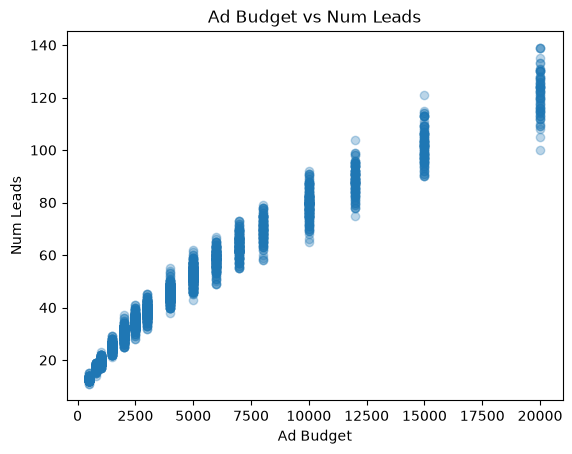

In [6]:
import matplotlib.pyplot as plt

plt.scatter(df['ad_budget'], df['num_leads'], alpha=0.3)
plt.xlabel('Ad Budget')
plt.ylabel('Num Leads')
plt.title('Ad Budget vs Num Leads')
plt.show()

In [ ]:
df['leads_per_budget'] = df['num_leads'] / df['ad_budget']

# ממוצע היחס לפי דרגת תקציב
df['budget_tier'] = pd.cut(
    df['ad_budget'], bins=[0, 1500, 5000, float('inf')], labels=['Low', 'Mid', 'High']
)
df.groupby('budget_tier')['leads_per_budget'].mean()

In [9]:
df['conversion_rate'] = df['closed'] / df['num_leads']
df.groupby('budget_tier')['conversion_rate'].mean()

budget_tier
Low     0.045242
Mid     0.082196
High    0.054335
Name: conversion_rate, dtype: float64

In [ ]:
# רק לקוחות שבאמת רכשו — יש להם ltv_months תקין
df_ltv = df[df['purchased'] == 1].copy()

features = ['ad_budget', 'num_leads', 'leads_answered', 'leads_not_answered',
            'followup_1', 'followup_2', 'followup_3', 'followup_4', 'followup_5',
            'calls_to_closed', 'calls_to_not_closed', 'customer_acquisition_cost']

X = df_ltv[features]
y = df_ltv['ltv_months']

X.shape, y.shape